In [2]:
import os
import zipfile
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
from PIL import Image
import numpy as np
import pandas as pd

try:
    import onnx
except ModuleNotFoundError:
    !pip install onnx onnxruntime onnxruntime-gpu
    import onnx

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GRAYSCALE   = True
IN_CHANNELS = 1 if GRAYSCALE else 3
print(f"Device     : {DEVICE}")
print(f"In channels: {IN_CHANNELS} ({'grayscale' if GRAYSCALE else 'RGB'})")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 5.4 MB/s eta 0:00:00
Device     : cpu
In channels: 1 (grayscale)


In [3]:
MODE = 'inference'   # 'custom' | 'inference' | 'export'

# ── Custom architecture (used when MODE = 'custom') ──────────────────────────
CUSTOM = {
    "ch1"          : 16,
    "ch2"          : 32,
    "ch3"          : 64,
    "dropout"      : 0.7,
    "lr"           : 3e-4,
    "weight_decay" : 1e-3,
}

FULL_EPOCHS = 30
BATCH_SIZE  = 64
CHECKPOINT  = "/content/drive/MyDrive/best_model.pth"

GDRIVE_ZIP_PATH = "/content/drive/MyDrive/dataset_30000.zip"
EXTRACT_DIR     = "/content/dataset/"

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.2
TEST_RATIO  = 0.1

IMAGE_SIZE  = 64

# ── Inference settings ───────────────────────────────────────────────────────
random.seed()
TRUE_LABEL  = "LEO"
IMAGE_INDEX = random.randint(0, 9) + (0 if TRUE_LABEL == "ORI" else (10 if TRUE_LABEL == "LEO" else 20))
IMAGE_PATH  = f"/content/drive/MyDrive/output_test30/{IMAGE_INDEX}_{TRUE_LABEL}_view{IMAGE_INDEX%10}_nolines_log.png"

# ── Export paths ─────────────────────────────────────────────────────────────
ONNX_PATH         = "/content/drive/MyDrive/systolic_cnn.onnx"
NUMPY_EXPORT_DIR  = "/content/drive/MyDrive/quantized_weights/"   # folder for .npy files

# ── Assertions ───────────────────────────────────────────────────────────────
assert MODE in ('custom', 'inference', 'export'), \
    "MODE must be 'custom', 'inference' or 'export'"
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, \
    "TRAIN_RATIO + VAL_RATIO + TEST_RATIO must equal 1.0"
print(f"Mode : {MODE}")

Mode : inference


In [4]:
from google.colab import drive
drive.mount('/content/drive')

if not os.path.exists(EXTRACT_DIR):
    print(f"Unzipping {GDRIVE_ZIP_PATH} → {EXTRACT_DIR} ...")
    with zipfile.ZipFile(GDRIVE_ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print(f"Dataset already extracted at {EXTRACT_DIR}, skipping unzip.")

CLASSES     = sorted([d for d in os.listdir(EXTRACT_DIR)
                       if os.path.isdir(os.path.join(EXTRACT_DIR, d))])
NUM_CLASSES = len(CLASSES)
print(f"Classes ({NUM_CLASSES}): {CLASSES}")

Mounted at /content/drive
Unzipping /content/drive/MyDrive/dataset_30000.zip → /content/dataset/ ...
Done.
Classes (3): ['LEO', 'ORI', 'SCO']


In [5]:
NORM_MEAN = (0.5,) if GRAYSCALE else (0.5, 0.5, 0.5)
NORM_STD  = (0.5,) if GRAYSCALE else (0.5, 0.5, 0.5)

_grayscale_tf = [transforms.Grayscale(num_output_channels=1)] if GRAYSCALE else []

train_tf = transforms.Compose(
    _grayscale_tf + [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(IMAGE_SIZE, padding=4),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD),
    ]
)

eval_tf = transforms.Compose(
    _grayscale_tf + [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD),
    ]
)

full_dataset      = torchvision.datasets.ImageFolder(EXTRACT_DIR, transform=train_tf)
full_eval_dataset = torchvision.datasets.ImageFolder(EXTRACT_DIR, transform=eval_tf)

random.seed(42)
indices_by_class = {}
for idx, (_, label) in enumerate(full_dataset.samples):
    indices_by_class.setdefault(label, []).append(idx)

train_idx, val_idx, test_idx = [], [], []
for label, idxs in indices_by_class.items():
    random.shuffle(idxs)
    n     = len(idxs)
    n_tr  = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    train_idx.extend(idxs[:n_tr])
    val_idx.extend(idxs[n_tr:n_tr + n_val])
    test_idx.extend(idxs[n_tr + n_val:])

train_set = Subset(full_dataset,      train_idx)
val_set   = Subset(full_eval_dataset, val_idx)
test_set  = Subset(full_eval_dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train : {len(train_set):,} images")
print(f"Val   : {len(val_set):,} images")
print(f"Test  : {len(test_set):,} images")


Train : 21,000 images
Val   : 6,000 images
Test  : 3,000 images


In [6]:
class TinyBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=False):
        super().__init__()
        ops = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            ops.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*ops)

    def forward(self, x):
        return self.block(x)

In [7]:
class SystolicCNN(nn.Module):
    def __init__(self, ch1=16, ch2=32, ch3=64, dropout=0.3, num_classes=10):
        super().__init__()
        self.ch1, self.ch2, self.ch3 = ch1, ch2, ch3
        self.dropout_p = dropout

        self.features = nn.Sequential(
            TinyBlock(IN_CHANNELS, ch1, pool=True),
            TinyBlock(ch1,         ch2, pool=True),
            TinyBlock(ch2,         ch3, pool=True),
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(ch3, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)

    def print_architecture(self):
        ch1, ch2, ch3 = self.ch1, self.ch2, self.ch3
        total_params  = sum(p.numel() for p in self.parameters() if p.requires_grad)

        s    = IMAGE_SIZE
        c1_p = (IN_CHANNELS * 9 * ch1) + ch1 * 2
        c2_p = (ch1 * 9 * ch2)         + ch2 * 2
        c3_p = (ch2 * 9 * ch3)         + ch3 * 2
        fc_p = ch3 * NUM_CLASSES + NUM_CLASSES

        c1_m = IN_CHANNELS * 9 * ch1 * (s//2)  * (s//2)
        c2_m = ch1         * 9 * ch2 * (s//4)  * (s//4)
        c3_m = ch2         * 9 * ch3 * (s//8)  * (s//8)
        fc_m = ch3 * NUM_CLASSES
        total_macs = c1_m + c2_m + c3_m + fc_m

        W = 72
        print(); print("=" * W)
        print("  ARCHITECTURE SUMMARY"); print("=" * W)
        ch_label = "grayscale" if GRAYSCALE else "RGB"
        print(f"  Input   : {IN_CHANNELS} x {s} x {s}  ({ch_label})    Dropout : {self.dropout_p}")
        print()
        print(f"  {'Layer':<26} {'Channels':>12}  {'Kernel':>6}  {'Output':>12}  {'Params':>7}  {'MACs':>9}")
        print("-" * W)
        rows = [
            ("Conv1 + BN + ReLU",  f"{IN_CHANNELS} -> {ch1}", "3x3", f"{ch1} x {s//2}x{s//2}",   c1_p, c1_m),
            ("  MaxPool2d",        "—",                        "2x2", f"{ch1} x {s//4}x{s//4}",   0,    0),
            ("Conv2 + BN + ReLU",  f"{ch1} -> {ch2}",         "3x3", f"{ch2} x {s//4}x{s//4}",   c2_p, c2_m),
            ("  MaxPool2d",        "—",                        "2x2", f"{ch2} x {s//8}x{s//8}",   0,    0),
            ("Conv3 + BN + ReLU",  f"{ch2} -> {ch3}",         "3x3", f"{ch3} x {s//8}x{s//8}",   c3_p, c3_m),
            ("  MaxPool2d",        "—",                        "2x2", f"{ch3} x {s//16}x{s//16}", 0,    0),
            ("GlobalAvgPool",      "—",                        "—",   f"{ch3} x 1x1",              0,    0),
            ("Flatten",            "—",                        "—",   f"{ch3}",                    0,    0),
            (f"Dropout({self.dropout_p})", "—",                "—",   f"{ch3}",                    0,    0),
            ("Linear",             f"{ch3} -> {NUM_CLASSES}",  "—",   f"{NUM_CLASSES}",            fc_p, fc_m),
        ]
        for name, ch, k, out, p, m in rows:
            print(f"  {name:<26} {ch:>12}  {k:>6}  {out:>12}  {f'{p:,}' if p else '—':>7}  {f'{m:,}' if m else '—':>9}")
        print("-" * W)
        print(f"  {'TOTAL':<26} {'':>12}  {'':>6}  {'':>12}  {total_params:>7,}  {total_macs:>9,}")
        print("=" * W); print()

print("Model defined.")

Model defined.


In [8]:
def train_full(model, lr, weight_decay, epochs):
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/100)

    best_acc = 0.0
    history  = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": []}

    print(f"\n{'Ep':>3} | {'Tr Loss':>7} | {'Tr Acc':>6} | {'Va Loss':>7} | {'Va Acc':>6} | {'Time':>5}")
    print("-" * 50)

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            out  = model(imgs)
            loss = crit(out, labels)
            loss.backward()
            opt.step()
            tr_loss    += loss.item() * labels.size(0)
            tr_correct += out.argmax(1).eq(labels).sum().item()
            tr_total   += labels.size(0)

        model.eval()
        va_loss, va_correct, va_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out         = model(imgs)
                va_loss    += crit(out, labels).item() * labels.size(0)
                va_correct += out.argmax(1).eq(labels).sum().item()
                va_total   += labels.size(0)

        tr_acc = 100. * tr_correct / tr_total
        va_acc = 100. * va_correct / va_total
        sched.step()
        history["tr_loss"].append(tr_loss / tr_total)
        history["va_loss"].append(va_loss / va_total)
        history["tr_acc"].append(tr_acc)
        history["va_acc"].append(va_acc)

        if va_acc >= best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), CHECKPOINT)

        flag = " ✓" if va_acc >= best_acc else "  "
        print(f"{epoch:>3} | {tr_loss/tr_total:>7.4f} | {tr_acc:>5.1f}% | "
              f"{va_loss/va_total:>7.4f} | {va_acc:>5.1f}%{flag} | {time.time()-t0:>4.1f}s")

    print(f"\nBest val accuracy  : {best_acc:.2f}%")
    print(f"Checkpoint saved   -> {CHECKPOINT}")

    eps = range(1, epochs + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Training History", fontsize=14, fontweight="bold")
    ax1.plot(eps, history["tr_loss"], label="Train loss", color="#2980b9", linewidth=2)
    ax1.plot(eps, history["va_loss"], label="Val loss",   color="#e74c3c", linewidth=2)
    best_ep = history["va_loss"].index(min(history["va_loss"])) + 1
    ax1.axvline(best_ep, color="#e74c3c", linestyle="--", alpha=0.4, label=f"Best epoch ({best_ep})")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(eps, history["tr_acc"], label="Train acc", color="#2980b9", linewidth=2)
    ax2.plot(eps, history["va_acc"], label="Val acc",   color="#e74c3c", linewidth=2)
    ax2.axvline(best_ep, color="#e74c3c", linestyle="--", alpha=0.4, label=f"Best epoch ({best_ep})")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.set_title("Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return best_acc

def evaluate_on_test(model):
    """Report per-class accuracy on the held-out test set."""
    model.eval()
    cc = [0] * NUM_CLASSES
    ct = [0] * NUM_CLASSES
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(1)
            for lbl, pred in zip(labels, preds):
                ct[lbl] += 1
                cc[lbl] += int(pred == lbl)

    overall = 100 * sum(cc) / sum(ct)
    print(f"\nTest-set overall accuracy: {overall:.2f}%")
    print("\nPer-class accuracy (test set):")
    for i, cls in enumerate(CLASSES):
        pct = 100 * cc[i] / ct[i] if ct[i] else 0.0
        bar = "█" * int(pct // 5)
        print(f"  {cls:>12s}: {pct:5.1f}%  {bar}")

print("Utilities defined.")


Utilities defined.


  MODE: INFERENCE — single image classification

Loading checkpoint: /content/drive/MyDrive/best_model.pth

  ARCHITECTURE SUMMARY
  Input   : 1 x 64 x 64  (grayscale)    Dropout : 0.7

  Layer                          Channels  Kernel        Output   Params       MACs
------------------------------------------------------------------------
  Conv1 + BN + ReLU               1 -> 16     3x3    16 x 32x32      176    147,456
    MaxPool2d                           —     2x2    16 x 16x16        —          —
  Conv2 + BN + ReLU              16 -> 32     3x3    32 x 16x16    4,672  1,179,648
    MaxPool2d                           —     2x2      32 x 8x8        —          —
  Conv3 + BN + ReLU              32 -> 64     3x3      64 x 8x8   18,560  1,179,648
    MaxPool2d                           —     2x2      64 x 4x4        —          —
  GlobalAvgPool                         —       —      64 x 1x1        —          —
  Flatten                               —       —            64      

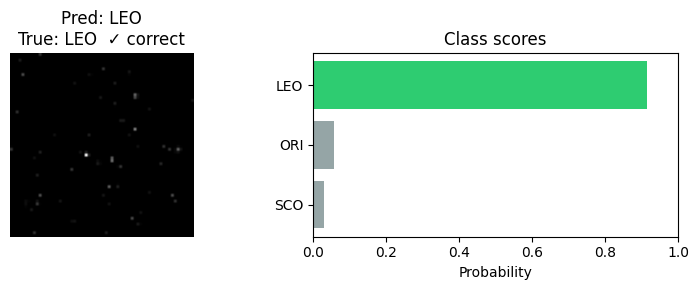

In [9]:
if MODE == 'custom':
    print("=" * 50)
    print("  MODE: CUSTOM — user-defined architecture")
    print("=" * 50)
    print("\nUsing config:")
    for k, v in CUSTOM.items():
        print(f"  {k:>15} : {v}")

    model = SystolicCNN(
        ch1         = CUSTOM["ch1"],
        ch2         = CUSTOM["ch2"],
        ch3         = CUSTOM["ch3"],
        dropout     = CUSTOM["dropout"],
        num_classes = NUM_CLASSES,
    ).to(DEVICE)

    model.print_architecture()
    print(f"Training for {FULL_EPOCHS} epochs...")
    train_full(model, lr=CUSTOM["lr"], weight_decay=CUSTOM["weight_decay"], epochs=FULL_EPOCHS)
    model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
    evaluate_on_test(model)

elif MODE == 'inference':
    print("=" * 50)
    print("  MODE: INFERENCE — single image classification")
    print("=" * 50)

    print(f"\nLoading checkpoint: {CHECKPOINT}")
    try:
        state = torch.load(CHECKPOINT, map_location=DEVICE)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No checkpoint found at '{CHECKPOINT}'. "
            "Run MODE='custom' first to train and save a model."
        )

    model = SystolicCNN(
        ch1         = CUSTOM["ch1"],
        ch2         = CUSTOM["ch2"],
        ch3         = CUSTOM["ch3"],
        dropout     = CUSTOM["dropout"],
        num_classes = NUM_CLASSES,
    ).to(DEVICE)
    model.load_state_dict(state)
    model.eval()
    model.print_architecture()

    pil_img = Image.open(IMAGE_PATH).convert("L" if GRAYSCALE else "RGB")

    raw_tf = transforms.Compose(
        ([transforms.Grayscale(1)] if GRAYSCALE else []) + [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
        ]
    )
    infer_tf = transforms.Compose(
        ([transforms.Grayscale(1)] if GRAYSCALE else []) + [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(NORM_MEAN, NORM_STD),
        ]
    )

    raw_tensor = raw_tf(pil_img)
    img_tensor = infer_tf(pil_img).unsqueeze(0).to(DEVICE)

    print(f"\n--- Inference diagnostics ---")
    print(f"CLASSES        : {CLASSES}")
    print(f"PIL mode       : {pil_img.mode}")
    print(f"Tensor shape   : {img_tensor.shape}")
    print(f"Tensor min/max : {img_tensor.min():.2f} / {img_tensor.max():.2f}")
    print(f"-----------------------------\n")

    with torch.no_grad():
        logits = model(img_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()

    pred_label = probs.argmax().item()

    if TRUE_LABEL is not None:
        assert TRUE_LABEL in CLASSES, \
            f"TRUE_LABEL '{TRUE_LABEL}' not found in CLASSES {CLASSES}"
        true_idx    = CLASSES.index(TRUE_LABEL)
        correct_str = "✓ correct" if pred_label == true_idx else "✗ wrong"
    else:
        true_idx    = None
        correct_str = ""

    print(f"Image path   : {IMAGE_PATH}")
    if TRUE_LABEL is not None:
        print(f"True label   : {TRUE_LABEL}")
    print(f"Predicted    : {CLASSES[pred_label]}  {correct_str}")
    print("\nClass probabilities:")
    for i, cls in enumerate(CLASSES):
        bar = "█" * int(probs[i].item() * 40)
        print(f"  {cls:>12s}: {probs[i].item()*100:5.1f}%  {bar}")

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    cmap = "gray" if GRAYSCALE else None
    axes[0].imshow(raw_tensor.squeeze(), cmap=cmap)
    title = f"Pred: {CLASSES[pred_label]}"
    if TRUE_LABEL is not None:
        title += f"\nTrue: {TRUE_LABEL}  {correct_str}"
    axes[0].set_title(title, fontsize=12); axes[0].axis("off")
    colors = [
        "#2ecc71" if i == pred_label and (true_idx is None or pred_label == true_idx)
        else "#e74c3c" if i == pred_label and pred_label != true_idx
        else "#3498db" if i == true_idx
        else "#95a5a6"
        for i in range(NUM_CLASSES)
    ]
    axes[1].barh(CLASSES, probs.cpu().numpy(), color=colors)
    axes[1].set_xlim(0, 1); axes[1].set_xlabel("Probability")
    axes[1].set_title("Class scores"); axes[1].invert_yaxis()
    plt.tight_layout(); plt.show()

In [10]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds   = model(imgs).argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
print(f"Test accuracy: {100.*correct/total:.2f}%")

all_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1)
        all_preds.extend(preds.cpu().tolist())
print(f"Prediction distribution: {Counter(all_preds)}")
print(f"Expected ~{len(all_preds)//NUM_CLASSES} per class")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 100.00%
Prediction distribution: Counter({0: 1000, 1: 1000, 2: 1000})
Expected ~1000 per class


In [ ]:
# .pth
torch.save(model.state_dict(), CHECKPOINT)
print(f"✓ .pth checkpoint saved  -> {CHECKPOINT}")
import onnx
# ONNX
print("\n--- EXPORTING ONNX MODEL ---")
model.eval()
dummy_input = torch.randn(1, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamo=False
)
print(f"✓ ONNX model saved       -> {ONNX_PATH}")

✓ .pth checkpoint saved  -> /content/drive/MyDrive/best_model.pth

--- EXPORTING ONNX MODEL ---
✓ ONNX model saved       -> /content/drive/MyDrive/systolic_cnn.onnx


/tmp/ipykernel_12444/3222331709.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
#  This cell:
#    1. Fuses BatchNorm into preceding Conv weights (BN has no separate op on
#       your systolic array — the scale/shift is absorbed into the kernel).
#    2. Applies symmetric per-channel affine quantization:
#         scale[oc] = max(|W[oc]|) / 127
#         W_int8    = clip(round(W / scale), -128, 127)
#    3. Quantizes biases to int32 using  bias_scale = w_scale * input_scale
#    4. Reshapes each conv weight to [OC, IC*kH*kW] — im2col-ready.
#    5. Saves every layer's W (int8), B (int32), and scales as separate .npy
#       files so you can load them individually on your hardware toolchain.
#
#  Output directory layout (NUMPY_EXPORT_DIR):
#    conv1_W_int8.npy          shape [16,  9]   (OC=16, IC*kH*kW = 1*3*3)
#    conv1_B_int32.npy         shape [16]
#    conv1_w_scales.npy        shape [16]        per-channel weight scales
#    conv1_b_scale.npy         scalar            bias scale = w_scale*input_scale
#    conv2_W_int8.npy          shape [32, 144]   (IC*kH*kW = 16*3*3)
#    conv2_B_int32.npy         shape [32]
#    ...
#    fc_W_int8.npy             shape [NUM_CLASSES, ch3]
#    fc_B_int32.npy            shape [NUM_CLASSES]
#    quantization_report.txt   human-readable SNR + scale table
# =============================================================================

if MODE == 'export':
    model.eval()
    os.makedirs(NUMPY_EXPORT_DIR, exist_ok=True)

    INPUT_SCALE = 1.0 / 255.0   # assumes uint8 [0,255] input to systolic array


    # ── Helper: fuse BN into Conv ─────────────────────────────────────────────────
    def fuse_bn_into_conv(conv, bn):
        """
        Returns (fused_weight, fused_bias) as float32 numpy arrays.

        Derivation:
            y = BN(Conv(x))
            = γ * (W*x + b - μ) / sqrt(σ²+ε) + β
            Fused:
            W_f = γ / sqrt(σ²+ε)  *  W          (per output channel)
            b_f = γ * (b - μ) / sqrt(σ²+ε) + β
        """
        W  = conv.weight.detach().float()          # [OC, IC, kH, kW]
        b  = conv.bias.detach().float() if conv.bias is not None \
            else torch.zeros(W.shape[0])          # conv bias (often 0 / absent)

        γ  = bn.weight.detach().float()            # BN scale
        β  = bn.bias.detach().float()              # BN shift
        μ  = bn.running_mean.detach().float()      # BN running mean
        σ2 = bn.running_var.detach().float()       # BN running variance
        ε  = bn.eps

        scale = γ / torch.sqrt(σ2 + ε)            # [OC]
        W_f   = W * scale.view(-1, 1, 1, 1)       # broadcast over IC, kH, kW
        b_f   = scale * (b - μ) + β

        return W_f.numpy(), b_f.numpy()


    # ── Helper: symmetric per-channel int8 quantization ──────────────────────────
    def quantize_weights_per_channel(W_np):
        """
        W_np : float32 [OC, ...]
        Returns:
            W_q      : int8   [OC, ...]
            scales   : float32 [OC]
        """
        OC     = W_np.shape[0]
        W_flat = W_np.reshape(OC, -1)              # [OC, IC*kH*kW]
        scales = np.max(np.abs(W_flat), axis=1) / 127.0   # [OC]
        scales = np.where(scales == 0, 1e-8, scales)       # avoid div-by-zero

        W_q = np.clip(
            np.round(W_flat / scales[:, None]),
            -128, 127
        ).astype(np.int8)                          # [OC, IC*kH*kW]

        return W_q, scales


    # ── Helper: int32 bias quantization ──────────────────────────────────────────
    def quantize_bias_int32(b_np, w_scales, input_scale):
        """
        Each output channel has its own bias scale = w_scale[oc] * input_scale.
        b_np      : float32 [OC]
        w_scales  : float32 [OC]
        Returns:
            b_q       : int32 [OC]
            b_scales  : float32 [OC]
        """
        b_scales = w_scales * input_scale          # [OC]
        b_scales = np.where(b_scales == 0, 1e-8, b_scales)
        b_q = np.clip(
            np.round(b_np / b_scales),
            -(2**31), 2**31 - 1
        ).astype(np.int32)
        return b_q, b_scales


    # ── Helper: compute SNR for sanity check ─────────────────────────────────────
    def compute_snr(original, reconstructed):
        signal_power = np.var(original)
        noise_power  = np.var(original - reconstructed)
        if noise_power < 1e-12:
            return float('inf')
        return 10 * np.log10(signal_power / noise_power)


    # ── Extract TinyBlock conv+BN pairs from SystolicCNN ─────────────────────────
    #   features[0].block = [Conv2d, BatchNorm2d, ReLU, MaxPool2d]
    #   The conv is at index 0, BN at index 1 inside each TinyBlock.
    block_configs = [
        ("conv1", model.features[0].block[0], model.features[0].block[1]),
        ("conv2", model.features[1].block[0], model.features[1].block[1]),
        ("conv3", model.features[2].block[0], model.features[2].block[1]),
    ]

    #   FC layer — no BN to fuse
    fc_layer = model.classifier[2]               # Linear(ch3, NUM_CLASSES)

    report_lines = []
    report_lines.append(f"{'Layer':<10} {'Shape (W_int8)':>20}  {'SNR (dB)':>10}  {'w_scale min':>12}  {'w_scale max':>12}")
    report_lines.append("-" * 70)

    print("\n=== Affine Quantization Export ===\n")

    # ── Conv layers ───────────────────────────────────────────────────────────────
    for name, conv, bn in block_configs:
        # 1. Fuse BN
        W_f, b_f = fuse_bn_into_conv(conv, bn)    # float32

        # 2. Quantize weights  →  int8  [OC, IC*kH*kW]
        W_q, w_scales = quantize_weights_per_channel(W_f)

        # 3. Quantize biases   →  int32 [OC]
        b_q, b_scales = quantize_bias_int32(b_f, w_scales, INPUT_SCALE)

        # 4. SNR check (dequantize and compare)
        W_deq = (W_q.astype(np.float32) * w_scales[:, None])  # reconstruct
        snr   = compute_snr(W_f.reshape(W_f.shape[0], -1), W_deq)

        # 5. Save
        np.save(os.path.join(NUMPY_EXPORT_DIR, f"{name}_W_int8.npy"),    W_q)
        np.save(os.path.join(NUMPY_EXPORT_DIR, f"{name}_B_int32.npy"),   b_q)
        np.save(os.path.join(NUMPY_EXPORT_DIR, f"{name}_w_scales.npy"),  w_scales)
        np.save(os.path.join(NUMPY_EXPORT_DIR, f"{name}_b_scales.npy"),  b_scales)

        print(f"  {name}: W_int8 {W_q.shape}  B_int32 {b_q.shape}  SNR={snr:.1f} dB")
        report_lines.append(
            f"{name:<10} {str(W_q.shape):>20}  {snr:>10.2f}  "
            f"{w_scales.min():>12.6f}  {w_scales.max():>12.6f}"
        )

    # ── FC layer ──────────────────────────────────────────────────────────────────
    W_fc  = fc_layer.weight.detach().float().numpy()   # [NUM_CLASSES, ch3]
    b_fc  = fc_layer.bias.detach().float().numpy()     # [NUM_CLASSES]

    W_fc_q, w_fc_scales = quantize_weights_per_channel(W_fc)
    b_fc_q, b_fc_scales = quantize_bias_int32(b_fc, w_fc_scales, INPUT_SCALE)

    W_fc_deq = W_fc_q.astype(np.float32) * w_fc_scales[:, None]
    snr_fc   = compute_snr(W_fc, W_fc_deq)

    np.save(os.path.join(NUMPY_EXPORT_DIR, "fc_W_int8.npy"),    W_fc_q)
    np.save(os.path.join(NUMPY_EXPORT_DIR, "fc_B_int32.npy"),   b_fc_q)
    np.save(os.path.join(NUMPY_EXPORT_DIR, "fc_w_scales.npy"),  w_fc_scales)
    np.save(os.path.join(NUMPY_EXPORT_DIR, "fc_b_scales.npy"),  b_fc_scales)

    print(f"  fc:    W_int8 {W_fc_q.shape}  B_int32 {b_fc_q.shape}  SNR={snr_fc:.1f} dB")
    report_lines.append(
        f"{'fc':<10} {str(W_fc_q.shape):>20}  {snr_fc:>10.2f}  "
        f"{w_fc_scales.min():>12.6f}  {w_fc_scales.max():>12.6f}"
    )

    # ── Write report ─────────────────────────────────────────────────────────────
    report_path = os.path.join(NUMPY_EXPORT_DIR, "quantization_report.txt")
    with open(report_path, "w") as f:
        f.write("Affine Quantization Report\n")
        f.write("Symmetric per-channel int8 weights, int32 biases\n")
        f.write(f"Input scale : {INPUT_SCALE}\n\n")
        f.write("\n".join(report_lines))

    print(f"\n✓ All numpy arrays saved  -> {NUMPY_EXPORT_DIR}")
    print(f"✓ Quantization report     -> {report_path}")
    print("\nNOTE: SNR > 40 dB is healthy for int8. Lower values indicate")
    print("      high weight variance in that layer — expected for the FC layer.")

    # ── Quick dtype verification ─────────────────────────────────────────────────
    print("\n--- dtype verification ---")
    for fname in sorted(os.listdir(NUMPY_EXPORT_DIR)):
        if fname.endswith(".npy"):
            arr = np.load(os.path.join(NUMPY_EXPORT_DIR, fname))
            print(f"  {fname:<35} dtype={arr.dtype}  shape={arr.shape}")